# **CHAPTER 8: Dimensionality Reduction**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Each row is a point (x1, x2, x3)
X = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [3, 4, 5],
    [5, 6, 7],
    [6, 7, 8],
    [7, 8, 9],
    [1, 0, 2],
    [2, 1, 3],
    [3, 1, 4],
    [4, 2, 5]
])


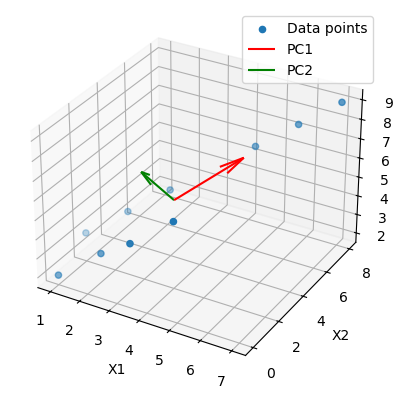

In [7]:
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

c1 = Vt[0]   # first principal direction
c2 = Vt[1]   # second principal direction

origin = X.mean(axis=0)

# --- Plot ---
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# data points
ax.scatter(X[:,0], X[:,1], X[:,2], label="Data points")

# principal directions (scaled for visibility)
ax.quiver(*origin, *(c1 * 3), color='r', label='PC1')
ax.quiver(*origin, *(c2 * 3), color='g', label='PC2')

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")

plt.legend()
plt.show()

PCA on 3 feature

In [25]:
df = pd.read_csv(r'/home/noneo/Codes/ML/MachineLearning/Datasets/purchase.csv')
df 

,Person,Ball,Bat,apple,Orange,Price
0,A,3.0,2.0,20.0,20.0,NaN
1,B,2.0,NaN,30.0,40.0,NaN
2,C,NaN,3.0,50.0,70.0,123.0
3,D,4.0,3.0,10.0,100.0,NaN
4,E,NaN,6.0,80.0,150.0,NaN
5,F,2.0,NaN,90.0,NaN,456.0
6,G,2.0,7.0,100.0,NaN,890.0
7,H,NaN,2.0,70.0,NaN,145.0
8,I,6.0,NaN,NaN,NaN,776.0
9,J,1.0,NaN,NaN,NaN,998.0


In [26]:
df['Ball'] = df['Ball'].fillna(df['Ball'].median())
df['apple'] = df['apple'].fillna(df["apple"].mean())
df['Orange'] = df['Orange'].fillna(df["Orange"].mean())
df['Price'] = df['Price'].fillna(df["Price"].median())
df['Bat'] = df['Bat'].fillna(df['Bat'].mean())
df

,Person,Ball,Bat,apple,Orange,Price
0,A,3.0,2.000000,20.00,20.0,616.0
1,B,2.0,3.833333,30.00,40.0,616.0
2,C,2.0,3.000000,50.00,70.0,123.0
3,D,4.0,3.000000,10.00,100.0,616.0
4,E,2.0,6.000000,80.00,150.0,616.0
5,F,2.0,3.833333,90.00,76.0,456.0
6,G,2.0,7.000000,100.00,76.0,890.0
7,H,2.0,2.000000,70.00,76.0,145.0
8,I,6.0,3.833333,56.25,76.0,776.0
9,J,1.0,3.833333,56.25,76.0,998.0


In [27]:
df = df.drop(['Person', 'apple'], axis=1)

In [14]:
import plotly.express as px
fig = px.scatter_3d(df, x='Ball', y='Bat', z='Orange',
                    color=df['Price'].astype(str)) # Keeps color discrete
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Separate features and target (Make sure df is your original DataFrame here!)
X = df.drop('Price', axis=1)
y = df['Price']

# 2. Scale the features (Assign to a NEW variable name so you don't overwrite X or df!)
ss = StandardScaler()
X_scaled = ss.fit_transform(X)

# 3. Calculate Covariance Matrix 
covariance_matrix = np.cov(X_scaled.T)

print("Covariance Matrix:\n", covariance_matrix)

Covariance Matrix:
 [[ 1.11111111 -0.18972823 -0.02020369]
 [-0.18972823  1.11111111  0.5622334 ]
 [-0.02020369  0.5622334   1.11111111]]


In [29]:

# Step 3 - Finding EV (Eigenvalues) and Eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

print("Eigenvalues:\n", eigen_values)
print("\nEigenvectors:\n", eigen_vectors)

Eigenvalues:
 [1.71085961 1.09887846 0.52359526]

Eigenvectors:
 [[ 0.24494016 -0.94733581 -0.20629875]
 [-0.70320164 -0.02709964 -0.71047383]
 [-0.66746668 -0.31909319  0.67280589]]


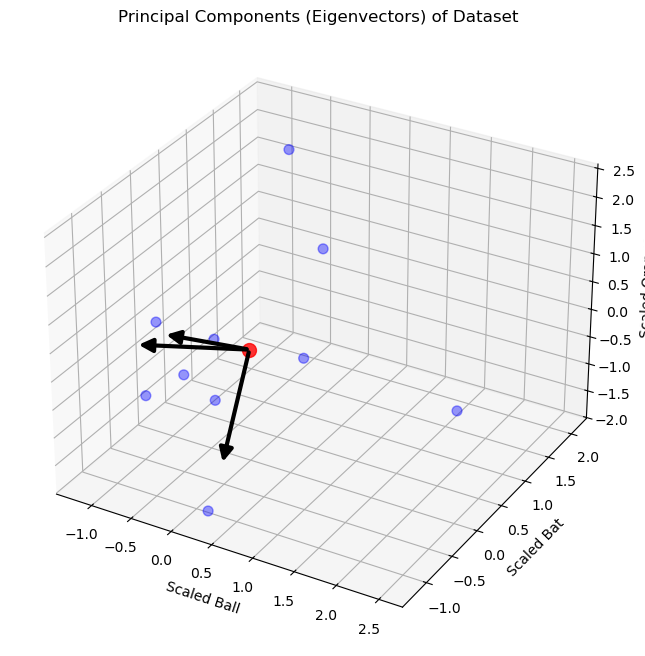

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

# 1. Define updated custom 3D Arrow class compatible with modern Matplotlib
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# 2. Initialize 3D Plot
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# 3. Plot scaled data points (Column 0: Ball, Column 1: Bat, Column 2: Orange)
ax.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], color='blue', alpha=0.4, s=50)

# 4. Find the center/mean of the scaled dataset (Should be at [0,0,0])
mean_x = X_scaled[:, 0].mean()
mean_y = X_scaled[:, 1].mean()
mean_z = X_scaled[:, 2].mean()
ax.scatter([mean_x], [mean_y], [mean_z], color='red', alpha=0.8, s=100)

# 5. Plot the Eigenvectors pointing out from the dataset center
for v in eigen_vectors.T:
    # Scale up the vector slightly (multiplied by 1.5) so it stands out visually
    a = Arrow3D([mean_x, mean_x + v[0] * 1.5], 
                [mean_y, mean_y + v[1] * 1.5], 
                [mean_z, mean_z + v[2] * 1.5], 
                mutation_scale=20, lw=3, arrowstyle="-|>", color="black")
    ax.add_artist(a)

# 6. Set labels using your actual feature names
ax.set_xlabel('Scaled Ball')
ax.set_ylabel('Scaled Bat')
ax.set_zlabel('Scaled Orange')
plt.title('Principal Components (Eigenvectors) of Dataset')

plt.show()

In [32]:

# 1. Select the top 2 principal components (eigenvectors)
# Since np.linalg.eig returns them as columns, we take the first two columns
pc = eigen_vectors[:, 0:2]

# 2. Transform the scaled dataset by multiplying it with the principal components
# X_scaled is shape (N, 3) and pc is shape (3, 2) -> result is shape (N, 2)
transformed_data = np.dot(X_scaled, pc)

# 3. Create a new DataFrame for the 2D data
new_df = pd.DataFrame(transformed_data, columns=['PC1', 'PC2'])

# 4. Bring back your original target column ('Price') to match the new rows
new_df['Price'] = y.values

# Look at the final, dimensionality-reduced dataset
print(new_df.head())

        PC1       PC2  Price
0  2.077818  0.304457  616.0
1  0.632496  0.773201  616.0
2  0.402935  0.493005  123.0
3  0.146714 -1.198908  616.0
4 -2.639475 -0.347843  616.0


In [41]:
import plotly.express as px

# 1. Keep 'Price' numerical (Do NOT convert it to a string)
new_df['Price'] = new_df['Price'].astype(float)

# 2. Build the plot using continuous color scaling
fig = px.scatter(
    new_df,               # Pass the dataframe first
    x='PC1',              # Use column names directly as strings
    y='PC2',
    color='Price',        # Plotly automatically applies a continuous color scale
    color_continuous_scale=px.colors.sequential.Viridis, # Clean gradient scale
    labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'}
)

# 3. Update marker styles
fig.update_traces(
    marker=dict(
        size=14,
        line=dict(width=1.5, color='DarkSlateGrey')
    ),
    selector=dict(mode='markers')
)

fig.show()

In [42]:
# **Singular Value Decomposition**